<a href="https://colab.research.google.com/github/Analyst-Femi-Ola-Joseph/ML-Analysis-of-Customer-Satisfaction/blob/main/ML_Analysis_of_Customer_Satisfaction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Importing Libraries

This section is used to import essential Python libraries used for data handling, visualisation, statistical testing and machine learning. The analysis uses pandas, NumPy, Matplotlib, SciPy, scikit-learn and imbalance-handling tools.

In [ ]:
# ================================
# SECTION 1: SETUP AND LIBRARIES
# ================================

import os
import re
import json
import zipfile
import warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from scipy.stats import chi2_contingency

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay
)
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
OUTPUT_DIR = Path("ld6053_final_outputs")
FIG_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
MODEL_DIR = OUTPUT_DIR / "model_outputs"

for folder in [OUTPUT_DIR, FIG_DIR, TABLE_DIR, MODEL_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Setup complete")
print("Output folder:", OUTPUT_DIR.resolve())

Setup complete
Output folder: /content/ld6053_final_outputs


In [ ]:
# ===============================================
# SECTION 3: INITIAL CHECK OF THE 9 DATASET FILES
# ===============================================

# The notebook accepts exact names and close variants such as "Labelled", "Labbeled" or "corrected_tags".
EXPECTED_DATASETS = {
    "tesco_trustpilot": {
        "retailer": "Tesco", "platform": "Trustpilot", "branch": "National",
        "keywords": ["tesco", "trustpilot"]
    },
    "asda_trustpilot": {
        "retailer": "Asda", "platform": "Trustpilot", "branch": "National",
        "keywords": ["asda", "trustpilot"]
    },
    "tesco_tilling_rd_google": {
        "retailer": "Tesco", "platform": "Google Reviews", "branch": "Tilling Rd",
        "keywords": ["tesco", "tilling"]
    },
    "tesco_cromwell_google": {
        "retailer": "Tesco", "platform": "Google Reviews", "branch": "Cromwell Rd",
        "keywords": ["tesco", "cromwell"]
    },
    "tesco_old_western_avenue_google": {
        "retailer": "Tesco", "platform": "Google Reviews", "branch": "Old Western Avenue",
        "keywords": ["tesco", "old", "western"]
    },
    "tesco_dunton_rd_google": {
        "retailer": "Tesco", "platform": "Google Reviews", "branch": "Dunton Rd",
        "keywords": ["tesco", "dunton"]
    },
    "asda_isle_of_dogs_google": {
        "retailer": "Asda", "platform": "Google Reviews", "branch": "Isle of Dogs",
        "keywords": ["asda", "isle", "dogs"]
    },
    "asda_beckton_google": {
        "retailer": "Asda", "platform": "Google Reviews", "branch": "Beckton",
        "keywords": ["asda", "beckton"]
    },
    "asda_wembley_google": {
        "retailer": "Asda", "platform": "Google Reviews", "branch": "Wembley",
        "keywords": ["asda", "wembley"]
    }
}


def normalise_filename(name):
    return re.sub(r"[^a-z0-9]+", "_", name.lower())


def available_spreadsheets(folder="."):
    files = []
    for f in os.listdir(folder):
        if f.lower().endswith((".xlsx", ".xls", ".csv")):
            files.append(f)
    return sorted(files)


def match_expected_files(files):
    matched = {}
    used = set()
    for dataset_key, info in EXPECTED_DATASETS.items():
        best = None
        for f in files:
            fn = normalise_filename(f)
            if f in used:
                continue
            if all(k in fn for k in info["keywords"]):
                best = f
                break
        if best:
            matched[dataset_key] = best
            used.add(best)
        else:
            matched[dataset_key] = None
    return matched

files = available_spreadsheets()
matched_files = match_expected_files(files)

print("Spreadsheet files currently available:")
for f in files:
    print(" -", f)

print("\nDataset matching status:")
for key, matched in matched_files.items():
    print(f"{key:35s} -> {matched}")

missing = [key for key, f in matched_files.items() if f is None]

if missing:
    print("\nMissing datasets:")
    for key in missing:
        print(" -", key)
    print("\nIf you are using Google Colab, run the upload block below.")
else:
    print("\nAll 9 datasets have been matched successfully.")

Spreadsheet files currently available:
 - Asda_Beckton_google_reviews Labelled.xlsx
 - Asda_Isle_of_Dogs_google_reviews Labelled.xlsx
 - Asda_Wembley_google_reviews Labbeled.xlsx
 - Tesco_Dunton_Rd_google_reviews Labelled.xlsx
 - Tesco_Old_Western_Avenue_Google_Reviews Labelled.xlsx
 - Tesco_cromwell_google_labelled_tags.xlsx
 - Tesco_tilling_rd_google_labelled_tags.xlsx
 - asda_trustpilot_corrected_tags.xlsx
 - tesco_trustpilot_3000_corrected_tags.xlsx

Dataset matching status:
tesco_trustpilot                    -> tesco_trustpilot_3000_corrected_tags.xlsx
asda_trustpilot                     -> asda_trustpilot_corrected_tags.xlsx
tesco_tilling_rd_google             -> Tesco_tilling_rd_google_labelled_tags.xlsx
tesco_cromwell_google               -> Tesco_cromwell_google_labelled_tags.xlsx
tesco_old_western_avenue_google     -> Tesco_Old_Western_Avenue_Google_Reviews Labelled.xlsx
tesco_dunton_rd_google              -> Tesco_Dunton_Rd_google_reviews Labelled.xlsx
asda_isle_of_dogs_goo

In [ ]:
# ============================================================
# SECTION 3A: COLAB UPLOAD PROMPT FOR THE 9 DATASET FILES
# ============================================================

# This upload prompt is included for reproducibility. It allows the notebook
# to be run from the beginning in Google Colab without assuming that the Excel
# files are already present in the working directory.

# Exact filenames used in the project at different stages may vary slightly.
# The notebook therefore uses the flexible matching dictionary already defined
# above in EXPECTED_DATASETS.

print("Checking whether the 9 Tesco and Asda review datasets are available...\n")

# Refresh the current spreadsheet list and matching status
files = available_spreadsheets()
matched_files = match_expected_files(files)
missing = [key for key, matched in matched_files.items() if matched is None]

print("Current dataset matching status before upload:")
for key, matched in matched_files.items():
    print(f"{key:35s} -> {matched}")

if missing:
    print("\nThe following expected dataset sources are missing:")
    for key in missing:
        info = EXPECTED_DATASETS[key]
        print(f" - {key} ({info['retailer']} | {info['platform']} | {info['branch']})")

    print("\nPlease upload the missing Excel/CSV files now. You may upload all 9 files again if easier.")

    try:
        from google.colab import files as colab_files
        uploaded = colab_files.upload()
        print("\nUploaded files:")
        for file_name in uploaded.keys():
            print(" -", file_name)
    except ModuleNotFoundError:
        print("\nGoogle Colab upload is not available in this environment.")
        print("If running locally, place the 9 dataset files in the same folder as this notebook and rerun this cell.")
else:
    print("\nAll 9 required dataset sources are already available. No upload is needed.")

# Final file check after upload / manual placement
files = available_spreadsheets()
matched_files = match_expected_files(files)
missing_after_upload = [key for key, matched in matched_files.items() if matched is None]

print("\nFinal dataset matching status after upload check:")
for key, matched in matched_files.items():
    print(f"{key:35s} -> {matched}")

if missing_after_upload:
    raise FileNotFoundError(
        "The notebook still cannot match all 9 expected datasets: " + ", ".join(missing_after_upload) +
        "\nCheck that the files were uploaded correctly and that their filenames contain the retailer/platform/branch keywords."
    )
else:
    print("\nAll 9 datasets are ready for loading and analysis.")


Checking whether the 9 Tesco and Asda review datasets are available...

Current dataset matching status before upload:
tesco_trustpilot                    -> tesco_trustpilot_3000_corrected_tags.xlsx
asda_trustpilot                     -> asda_trustpilot_corrected_tags.xlsx
tesco_tilling_rd_google             -> Tesco_tilling_rd_google_labelled_tags.xlsx
tesco_cromwell_google               -> Tesco_cromwell_google_labelled_tags.xlsx
tesco_old_western_avenue_google     -> Tesco_Old_Western_Avenue_Google_Reviews Labelled.xlsx
tesco_dunton_rd_google              -> Tesco_Dunton_Rd_google_reviews Labelled.xlsx
asda_isle_of_dogs_google            -> Asda_Isle_of_Dogs_google_reviews Labelled.xlsx
asda_beckton_google                 -> Asda_Beckton_google_reviews Labelled.xlsx
asda_wembley_google                 -> Asda_Wembley_google_reviews Labbeled.xlsx

All 9 required dataset sources are already available. No upload is needed.

Final dataset matching status after upload check:
tesco_trust

In [ ]:
# =====================================
# SECTION 3: LOAD AND AUDIT DATASETS
# =====================================

# Refresh file matching after upload
files = available_spreadsheets()
matched_files = match_expected_files(files)
missing = [key for key, f in matched_files.items() if f is None]

if missing:
    raise FileNotFoundError(
        "Some expected datasets are still missing: " + ", ".join(missing) +
        "\nPlease upload/place all 9 files, then rerun Section 2 and Section 3."
    )

raw_datasets = {}
audit_rows = []

for dataset_key, file_name in matched_files.items():
    path = Path(file_name)
    if path.suffix.lower() == ".csv":
        df = pd.read_csv(path)
    else:
        df = pd.read_excel(path)
    raw_datasets[dataset_key] = df
    audit_rows.append({
        "dataset_key": dataset_key,
        "file_name": file_name,
        "retailer": EXPECTED_DATASETS[dataset_key]["retailer"],
        "platform": EXPECTED_DATASETS[dataset_key]["platform"],
        "branch": EXPECTED_DATASETS[dataset_key]["branch"],
        "raw_rows": len(df),
        "raw_columns": df.shape[1],
        "columns_detected": ", ".join(map(str, df.columns[:12])) + ("..." if df.shape[1] > 12 else "")
    })

dataset_audit = pd.DataFrame(audit_rows)
dataset_audit.to_excel(TABLE_DIR / "01_dataset_audit_raw_sources.xlsx", index=False)
dataset_audit

,dataset_key,file_name,retailer,platform,branch,raw_rows,raw_columns,columns_detected
0,tesco_trustpilot,tesco_trustpilot_3000_corrected_tags.xlsx,Tesco,Trustpilot,National,3000,16,"Review No., Review Date, Review Rating, Review..."
1,asda_trustpilot,asda_trustpilot_corrected_tags.xlsx,Asda,Trustpilot,National,4000,16,"Review No., Review Date, Review Rating, Review..."
2,tesco_tilling_rd_google,Tesco_tilling_rd_google_labelled_tags.xlsx,Tesco,Google Reviews,Tilling Rd,761,28,"content, rating, reviewed_at_date, Retailer, P..."
3,tesco_cromwell_google,Tesco_cromwell_google_labelled_tags.xlsx,Tesco,Google Reviews,Cromwell Rd,1021,28,"content, rating, reviewed_at_date, Retailer, P..."
4,tesco_old_western_avenue_google,Tesco_Old_Western_Avenue_Google_Reviews Labell...,Tesco,Google Reviews,Old Western Avenue,684,15,"text, stars, Corrected Tags, Product_Quality, ..."
5,tesco_dunton_rd_google,Tesco_Dunton_Rd_google_reviews Labelled.xlsx,Tesco,Google Reviews,Dunton Rd,929,15,"stars, text, Corrected Tags, Product_Quality, ..."
6,asda_isle_of_dogs_google,Asda_Isle_of_Dogs_google_reviews Labelled.xlsx,Asda,Google Reviews,Isle of Dogs,1069,16,"rating, reviewed_at_date, content, Corrected T..."
7,asda_beckton_google,Asda_Beckton_google_reviews Labelled.xlsx,Asda,Google Reviews,Beckton,1267,16,"rating, reviewed_at_date, content, Corrected T..."
8,asda_wembley_google,Asda_Wembley_google_reviews Labbeled.xlsx,Asda,Google Reviews,Wembley,1459,16,"rating, reviewed_at_date, content, Corrected T..."


In [ ]:
# ======================================================
# SECTION 4: STANDARDISE REVIEW TEXT, RATING AND SOURCE
# ======================================================

RATING_CANDIDATES = [
    "rating", "stars", "star_rating", "review_rating", "score", "review_stars",
    "Rating", "Stars", "Star Rating", "Review Rating", "Score"
]

TEXT_CANDIDATES = [
    "review_text", "review", "text", "content", "comments", "comment", "description",
    "Review", "Review Text", "reviewText", "Review_Text", "Review_Text_Clean",
    "cleaned_review", "Cleaned Review", "body"
]

TAG_CANDIDATES = [
    "Corrected_Tags", "corrected_tags", "tags", "Tags", "tag", "Tag", "Main_Tag", "main_tag"
]


def find_column(df, candidates, contains_any=None):
    cols = list(df.columns)
    lowered = {str(c).lower().strip(): c for c in cols}
    for cand in candidates:
        key = cand.lower().strip()
        if key in lowered:
            return lowered[key]
    if contains_any:
        for c in cols:
            c_norm = str(c).lower().strip()
            if any(word in c_norm for word in contains_any):
                return c
    return None


def clean_rating(value):
    if pd.isna(value):
        return np.nan
    text = str(value).strip()
    # Extract first number, useful for values like "5 stars" or "Rated 4.0"
    match = re.search(r"\d+(?:\.\d+)?", text)
    if match:
        num = float(match.group(0))
        if 0 <= num <= 5:
            return num
    return np.nan


def clean_text(value):
    if pd.isna(value):
        return ""
    text = str(value)
    text = re.sub(r"\s+", " ", text).strip()
    return text

standardised_frames = []
standardise_audit = []

for dataset_key, df in raw_datasets.items():
    info = EXPECTED_DATASETS[dataset_key]
    rating_col = find_column(df, RATING_CANDIDATES, contains_any=["rating", "star", "score"])
    text_col = find_column(df, TEXT_CANDIDATES, contains_any=["review", "comment", "text", "content"])
    tag_col = find_column(df, TAG_CANDIDATES, contains_any=["tag", "theme", "category"])

    if rating_col is None:
        raise ValueError(f"No rating column detected for {dataset_key}. Columns: {list(df.columns)}")
    if text_col is None:
        raise ValueError(f"No review text column detected for {dataset_key}. Columns: {list(df.columns)}")

    temp = pd.DataFrame()
    temp["review_text"] = df[text_col].apply(clean_text)
    temp["rating"] = df[rating_col].apply(clean_rating)
    temp["raw_tags"] = df[tag_col].astype(str) if tag_col is not None else ""
    temp["retailer"] = info["retailer"]
    temp["platform"] = info["platform"]
    temp["branch"] = info["branch"]
    temp["dataset_key"] = dataset_key
    temp["source_file"] = matched_files[dataset_key]

    standardised_frames.append(temp)
    standardise_audit.append({
        "dataset_key": dataset_key,
        "rating_column_used": rating_col,
        "text_column_used": text_col,
        "tag_column_used": tag_col,
        "rows_before_cleaning": len(df),
        "rows_after_standardising": len(temp),
        "missing_rating_count": temp["rating"].isna().sum(),
        "empty_review_count": (temp["review_text"].str.len() == 0).sum()
    })

standardise_audit = pd.DataFrame(standardise_audit)
standardise_audit.to_excel(TABLE_DIR / "02_standardisation_audit.xlsx", index=False)
standardise_audit

,dataset_key,rating_column_used,text_column_used,tag_column_used,rows_before_cleaning,rows_after_standardising,missing_rating_count,empty_review_count
0,tesco_trustpilot,Review Rating,Review Text,Corrected Tags,3000,3000,0,0
1,asda_trustpilot,Review Rating,Review Text,Corrected Tags,4000,4000,0,0
2,tesco_tilling_rd_google,rating,content,Corrected_Tags,761,761,0,325
3,tesco_cromwell_google,rating,content,Corrected_Tags,1021,1021,0,356
4,tesco_old_western_avenue_google,stars,text,Corrected Tags,684,684,0,366
5,tesco_dunton_rd_google,stars,text,Corrected Tags,929,929,0,398
6,asda_isle_of_dogs_google,rating,content,Corrected Tags,1069,1069,0,268
7,asda_beckton_google,rating,content,Corrected Tags,1267,1267,0,526
8,asda_wembley_google,rating,content,Corrected Tags,1459,1459,0,619


In [ ]:
# =============================================
# SECTION 5: COMBINE DATASETS AND CREATE LABELS
# =============================================

reviews = pd.concat(standardised_frames, ignore_index=True)

# Remove rows without a valid rating or review text
reviews["rating"] = pd.to_numeric(reviews["rating"], errors="coerce")
reviews = reviews.dropna(subset=["rating"]).copy()
reviews = reviews[reviews["review_text"].str.len() > 0].copy()

# Create satisfaction labels
reviews["satisfaction_label"] = np.select(
    [reviews["rating"] <= 2, reviews["rating"] == 3, reviews["rating"] >= 4],
    ["Dissatisfied", "Neutral", "Satisfied"],
    default="Unknown"
)

# Binary ML data excludes neutral reviews
binary_reviews = reviews[reviews["satisfaction_label"].isin(["Dissatisfied", "Satisfied"])].copy()
binary_reviews["target"] = (binary_reviews["satisfaction_label"] == "Dissatisfied").astype(int)

summary_counts = pd.DataFrame({
    "stage": ["All valid reviews", "Binary ML reviews"],
    "row_count": [len(reviews), len(binary_reviews)]
})

label_counts = reviews["satisfaction_label"].value_counts().rename_axis("satisfaction_label").reset_index(name="count")
binary_counts = binary_reviews["satisfaction_label"].value_counts().rename_axis("satisfaction_label").reset_index(name="count")

summary_counts.to_excel(TABLE_DIR / "03_dataset_stage_counts.xlsx", index=False)
label_counts.to_excel(TABLE_DIR / "04_satisfaction_label_counts_all_reviews.xlsx", index=False)
binary_counts.to_excel(TABLE_DIR / "05_binary_class_counts.xlsx", index=False)

print("Original valid reviews:", len(reviews))
print("Binary ML reviews:", len(binary_reviews))
print("Neutral reviews excluded from binary modelling:", (reviews["satisfaction_label"] == "Neutral").sum())
print("\nAll label counts:")
print(label_counts)
print("\nBinary class counts:")
print(binary_counts)

Original valid reviews: 11332
Binary ML reviews: 10664
Neutral reviews excluded from binary modelling: 668

All label counts:
  satisfaction_label  count
0       Dissatisfied   7583
1          Satisfied   3081
2            Neutral    668

Binary class counts:
  satisfaction_label  count
0       Dissatisfied   7583
1          Satisfied   3081


In [ ]:
# ============================================
# SECTION 6: TEXT CLEANING AND TAG ENGINEERING
# ============================================

TAG_COLUMNS = [
    "product_quality", "customer_service", "delivery_online_order", "refunds_returns",
    "price_value", "store_experience", "checkout_queues", "app_website_clubcard",
    "app_website_rewards", "packaging", "staff_behaviour", "stock_availability",
    "parking", "cleanliness", "cafe_facilities", "accessibility_disability",
    "security", "other"
]

TAG_KEYWORDS = {
    "product_quality": ["product", "quality", "fresh", "food", "produce", "meat", "bakery"],
    "customer_service": ["customer_service", "customer service", "service", "support", "helpdesk"],
    "delivery_online_order": ["delivery", "online", "order", "home delivery", "click collect", "click and collect"],
    "refunds_returns": ["refund", "return", "returned", "money back", "exchange"],
    "price_value": ["price", "value", "expensive", "cheap", "cost", "offer", "clubcard price"],
    "store_experience": ["store", "experience", "shop", "shopping", "layout", "aisle"],
    "checkout_queues": ["checkout", "queue", "queues", "waiting", "till", "self checkout"],
    "app_website_clubcard": ["app", "website", "clubcard", "account", "login"],
    "app_website_rewards": ["reward", "rewards", "points", "voucher", "loyalty"],
    "packaging": ["packaging", "packed", "bag", "bags"],
    "staff_behaviour": ["staff", "rude", "manager", "employee", "security guard", "behaviour", "behavior"],
    "stock_availability": ["stock", "availability", "available", "shelves", "out of stock"],
    "parking": ["parking", "car park", "park"],
    "cleanliness": ["clean", "dirty", "toilet", "toilets", "hygiene", "mess"],
    "cafe_facilities": ["cafe", "facilities", "toilet", "baby", "trolley"],
    "accessibility_disability": ["disabled", "disability", "accessible", "accessibility", "wheelchair"],
    "security": ["security", "guard", "stolen", "theft", "accused"],
    "other": ["other", "misc"]
}


def clean_review_for_model(text):
    text = str(text).lower()
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"[^a-z0-9\s']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def normalise_tag_source(row):
    # Combine raw tags and review text to detect tags where binary columns are not already available.
    return f"{row.get('raw_tags', '')} {row.get('review_text', '')}".lower()


def add_tag_features(df):
    df = df.copy()
    df["review_text_clean"] = df["review_text"].apply(clean_review_for_model)

    # Start all tag columns at zero
    for tag in TAG_COLUMNS:
        df[tag] = 0

    # Use explicit existing binary tag columns if they are already present in original sources
    # and fallback to keyword detection from raw tags + review text.
    tag_source = df.apply(normalise_tag_source, axis=1)
    for tag, keywords in TAG_KEYWORDS.items():
        pattern = "|".join(re.escape(k.lower()) for k in keywords)
        df[tag] = tag_source.str.contains(pattern, regex=True, na=False).astype(int)

    # Ensure rows with no detected tag are placed in Other
    no_tag = df[TAG_COLUMNS].sum(axis=1) == 0
    df.loc[no_tag, "other"] = 1
    return df

reviews = add_tag_features(reviews)
binary_reviews = add_tag_features(binary_reviews)

# Save combined datasets for audit/evidence
reviews.to_excel(TABLE_DIR / "06_combined_all_reviews_cleaned.xlsx", index=False)
binary_reviews.to_excel(TABLE_DIR / "07_binary_reviews_cleaned_for_ml.xlsx", index=False)

print("Tag features created:", len(TAG_COLUMNS))
print(TAG_COLUMNS)

Tag features created: 18
['product_quality', 'customer_service', 'delivery_online_order', 'refunds_returns', 'price_value', 'store_experience', 'checkout_queues', 'app_website_clubcard', 'app_website_rewards', 'packaging', 'staff_behaviour', 'stock_availability', 'parking', 'cleanliness', 'cafe_facilities', 'accessibility_disability', 'security', 'other']


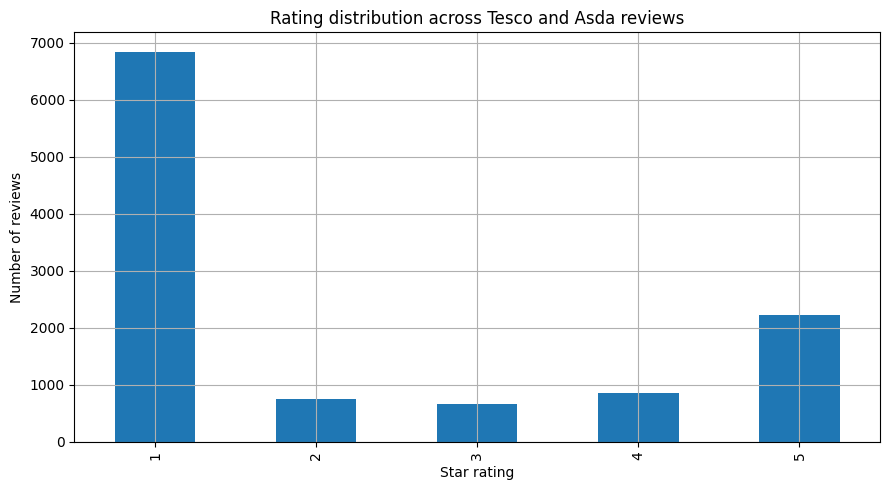

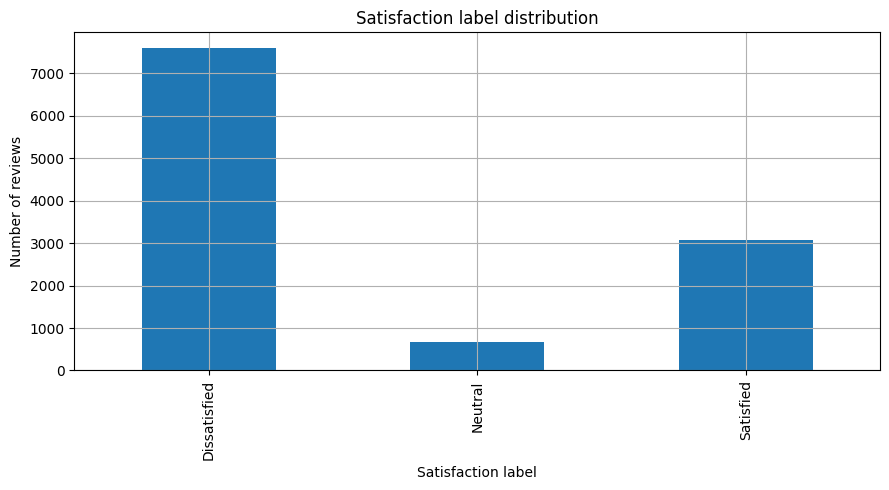

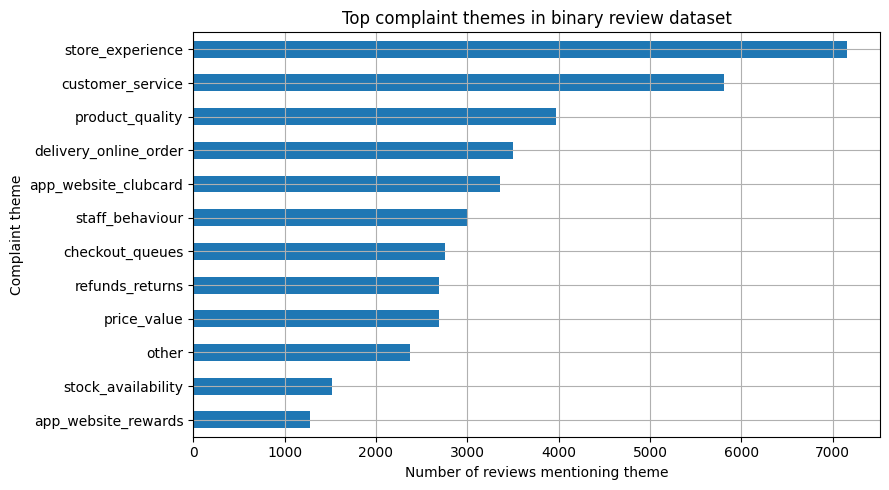

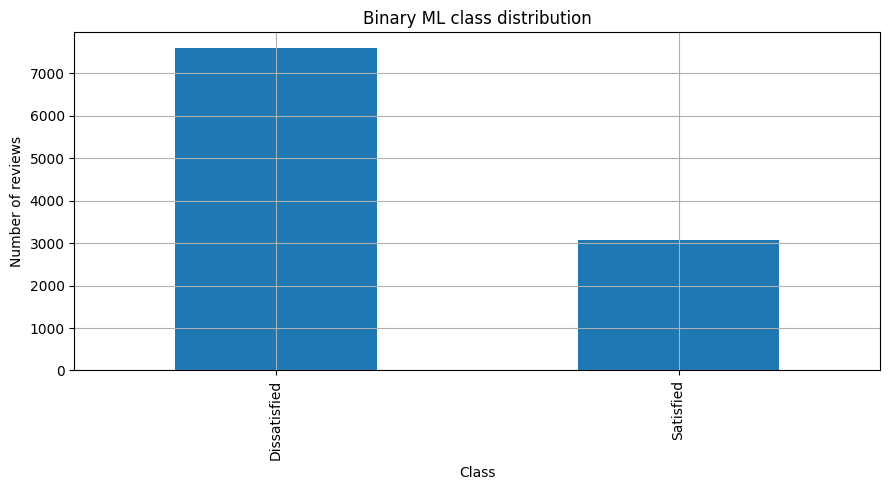

,retailer,platform,branch,review_count
0,Asda,Google Reviews,Beckton,741
1,Asda,Google Reviews,Isle of Dogs,801
2,Asda,Google Reviews,Wembley,840
3,Asda,Trustpilot,National,4000
4,Tesco,Google Reviews,Cromwell Rd,665


In [ ]:
# ==========================================
# SECTION 7: DESCRIPTIVE ANALYSIS AND CHARTS
# ==========================================

plt.rcParams.update({"figure.figsize": (9, 5), "axes.grid": True})

# 7.1 Rating distribution
rating_counts = reviews["rating"].round().astype(int).value_counts().sort_index()
rating_counts_df = rating_counts.rename_axis("rating").reset_index(name="count")
rating_counts_df.to_excel(TABLE_DIR / "08_rating_distribution.xlsx", index=False)

ax = rating_counts.plot(kind="bar")
ax.set_title("Rating distribution across Tesco and Asda reviews")
ax.set_xlabel("Star rating")
ax.set_ylabel("Number of reviews")
plt.tight_layout()
plt.savefig(FIG_DIR / "01_rating_distribution.png", dpi=200)
plt.show()

# 7.2 Satisfaction label distribution
label_order = ["Dissatisfied", "Neutral", "Satisfied"]
label_counts_series = reviews["satisfaction_label"].value_counts().reindex(label_order).fillna(0)
ax = label_counts_series.plot(kind="bar")
ax.set_title("Satisfaction label distribution")
ax.set_xlabel("Satisfaction label")
ax.set_ylabel("Number of reviews")
plt.tight_layout()
plt.savefig(FIG_DIR / "02_satisfaction_distribution.png", dpi=200)
plt.show()

# 7.3 Source counts
source_counts = reviews.groupby(["retailer", "platform", "branch"]).size().reset_index(name="review_count")
source_counts.to_excel(TABLE_DIR / "09_reviews_by_retailer_platform_branch.xlsx", index=False)

# 7.4 Top complaint tags
tag_counts = binary_reviews[TAG_COLUMNS].sum().sort_values(ascending=False).reset_index()
tag_counts.columns = ["complaint_tag", "count"]
tag_counts.to_excel(TABLE_DIR / "10_top_complaint_tags.xlsx", index=False)

ax = tag_counts.head(12).sort_values("count").plot(x="complaint_tag", y="count", kind="barh", legend=False)
ax.set_title("Top complaint themes in binary review dataset")
ax.set_xlabel("Number of reviews mentioning theme")
ax.set_ylabel("Complaint theme")
plt.tight_layout()
plt.savefig(FIG_DIR / "03_top_complaint_tags.png", dpi=200)
plt.show()

# 7.5 Binary class imbalance
binary_class_counts = binary_reviews["satisfaction_label"].value_counts().rename_axis("class").reset_index(name="count")
ax = binary_class_counts.plot(x="class", y="count", kind="bar", legend=False)
ax.set_title("Binary ML class distribution")
ax.set_xlabel("Class")
ax.set_ylabel("Number of reviews")
plt.tight_layout()
plt.savefig(FIG_DIR / "04_binary_class_imbalance.png", dpi=200)
plt.show()

source_counts.head()

In [ ]:
# ===================================
# SECTION 8: INFERENTIAL ANALYSIS
# ===================================


def cramers_v(confusion):
    chi2, p, dof, expected = chi2_contingency(confusion)
    n = confusion.sum().sum()
    r, k = confusion.shape
    if n == 0 or min(r - 1, k - 1) == 0:
        return np.nan
    return np.sqrt((chi2 / n) / min(k - 1, r - 1))

chi_results = []

# Categorical variables vs binary satisfaction label
for col in ["retailer", "platform", "branch"]:
    table = pd.crosstab(binary_reviews[col], binary_reviews["satisfaction_label"])
    chi2, p, dof, expected = chi2_contingency(table)
    chi_results.append({
        "variable": col,
        "chi_square": chi2,
        "p_value": p,
        "degrees_of_freedom": dof,
        "cramers_v": cramers_v(table),
        "interpretation": "Associated with satisfaction label" if p < 0.05 else "No statistically significant association detected"
    })

# Complaint tags vs binary satisfaction label
for tag in TAG_COLUMNS:
    table = pd.crosstab(binary_reviews[tag], binary_reviews["satisfaction_label"])
    if table.shape == (2, 2):
        chi2, p, dof, expected = chi2_contingency(table)
        chi_results.append({
            "variable": tag,
            "chi_square": chi2,
            "p_value": p,
            "degrees_of_freedom": dof,
            "cramers_v": cramers_v(table),
            "interpretation": "Associated with satisfaction label" if p < 0.05 else "No statistically significant association detected"
        })

chi_results_df = pd.DataFrame(chi_results).sort_values("cramers_v", ascending=False)
chi_results_df.to_excel(TABLE_DIR / "11_chi_square_cramers_v_results.xlsx", index=False)
chi_results_df.head(15)

,variable,chi_square,p_value,degrees_of_freedom,cramers_v,interpretation
2,branch,2656.429017,0.000000e+00,7,0.499102,Associated with satisfaction label
1,platform,2485.483178,0.000000e+00,1,0.482776,Associated with satisfaction label
5,delivery_online_order,1019.328865,1.129555e-223,1,0.309170,Associated with satisfaction label
6,refunds_returns,913.893255,9.367413e-201,1,0.292744,Associated with satisfaction label
10,app_website_clubcard,827.517497,5.615481e-182,1,0.278566,Associated with satisfaction label
4,customer_service,569.805054,6.190458e-126,1,0.231155,Associated with satisfaction label
11,app_website_rewards,443.148196,2.235028e-98,1,0.203852,Associated with satisfaction label
9,checkout_queues,339.376826,8.721419e-76,1,0.178394,Associated with satisfaction label
3,product_quality,265.069740,1.347330e-59,1,0.157659,Associated with satisfaction label
20,other,197.140026,8.789503e-45,1,0.135965,Associated with satisfaction label


In [ ]:
# ============================================
# SECTION 9: FEATURE AND TARGET DESIGN FOR ML
# ============================================

TEXT_COLUMN = "review_text_clean"
CAT_COLUMNS = ["retailer", "platform", "branch"]
TARGET_COLUMN = "target"

# Store modelling data
model_data = binary_reviews[[TEXT_COLUMN, TARGET_COLUMN, "satisfaction_label"] + CAT_COLUMNS + TAG_COLUMNS].copy()
model_data = model_data.dropna(subset=[TEXT_COLUMN, TARGET_COLUMN])

X = model_data[[TEXT_COLUMN] + CAT_COLUMNS + TAG_COLUMNS]
y = model_data[TARGET_COLUMN]

print("Model dataset shape:", model_data.shape)
print("Features used:")
print("Text:", TEXT_COLUMN)
print("Categorical:", CAT_COLUMNS)
print("Tags:", TAG_COLUMNS)
print("Target: 1 = Dissatisfied, 0 = Satisfied")

feature_design = pd.DataFrame([
    {"feature_group": "Review text", "columns": TEXT_COLUMN, "purpose": "Captures customer language and sentiment cues using TF-IDF."},
    {"feature_group": "Complaint tags", "columns": ", ".join(TAG_COLUMNS), "purpose": "Captures business themes such as service, refunds, queues and delivery."},
    {"feature_group": "Retail context", "columns": ", ".join(CAT_COLUMNS), "purpose": "Captures retailer, platform and branch context."},
    {"feature_group": "Excluded", "columns": "rating, satisfaction_label", "purpose": "Excluded to avoid data leakage."}
])
feature_design.to_excel(TABLE_DIR / "12_feature_design.xlsx", index=False)
feature_design

Model dataset shape: (10664, 24)
Features used:
Text: review_text_clean
Categorical: ['retailer', 'platform', 'branch']
Tags: ['product_quality', 'customer_service', 'delivery_online_order', 'refunds_returns', 'price_value', 'store_experience', 'checkout_queues', 'app_website_clubcard', 'app_website_rewards', 'packaging', 'staff_behaviour', 'stock_availability', 'parking', 'cleanliness', 'cafe_facilities', 'accessibility_disability', 'security', 'other']
Target: 1 = Dissatisfied, 0 = Satisfied


,feature_group,columns,purpose
0,Review text,review_text_clean,Captures customer language and sentiment cues ...
1,Complaint tags,"product_quality, customer_service, delivery_on...","Captures business themes such as service, refu..."
2,Retail context,"retailer, platform, branch","Captures retailer, platform and branch context."
3,Excluded,"rating, satisfaction_label",Excluded to avoid data leakage.


In [ ]:
# ============================================================
# SECTION 8A: TF-IDF FEATURE EXTRACTION SUMMARY TABLE
# Reporting table; this does not alter model training.
# ============================================================

tfidf_strategy_summary = pd.DataFrame({
    "Feature strategy": [
        "Word-level TF-IDF",
        "Character-level TF-IDF",
        "Complaint tags",
        "Contextual metadata"
    ],
    "How it is used": [
        "Captures important customer words and short phrases from review text",
        "Captures spelling variants and character patterns in customer language",
        "Adds interpretable business categories such as queues, delivery and staff behaviour",
        "Adds retailer, platform and branch context"
    ],
    "Purpose in the project": [
        "Improves text-based satisfaction prediction",
        "Strengthens the enhanced hybrid model",
        "Supports explainability and business interpretation",
        "Allows comparison across Tesco, Asda, Google Reviews, Trustpilot and branches"
    ]
})

tfidf_strategy_summary.to_excel(TABLE_DIR / "08A_tfidf_feature_strategy_summary.xlsx", index=False)
tfidf_strategy_summary

,Feature strategy,How it is used,Purpose in the project
0,Word-level TF-IDF,Captures important customer words and short ph...,Improves text-based satisfaction prediction
1,Character-level TF-IDF,Captures spelling variants and character patte...,Strengthens the enhanced hybrid model
2,Complaint tags,Adds interpretable business categories such as...,Supports explainability and business interpret...
3,Contextual metadata,"Adds retailer, platform and branch context","Allows comparison across Tesco, Asda, Google R..."


In [ ]:
# ================================
# SECTION 10: TRAIN / TEST SPLIT
# ================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

split_summary = pd.DataFrame({
    "split": ["train", "test"],
    "rows": [len(X_train), len(X_test)],
    "dissatisfied_count": [int(y_train.sum()), int(y_test.sum())],
    "satisfied_count": [int((y_train == 0).sum()), int((y_test == 0).sum())]
})
split_summary.to_excel(TABLE_DIR / "13_train_test_split_summary.xlsx", index=False)
split_summary

,split,rows,dissatisfied_count,satisfied_count
0,train,8531,6066,2465
1,test,2133,1517,616


In [ ]:
# ========================================
# SECTION 11: REUSABLE EVALUATION HELPERS
# ========================================


def get_scores_for_auc(model, X_test):
    """Return model scores for ROC-AUC. Works for models with decision_function or predict_proba."""
    if hasattr(model, "decision_function"):
        return model.decision_function(X_test)
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X_test)[:, 1]
    return None


def evaluate_model(model_name, model, X_test, y_test, notes=""):
    y_pred = model.predict(X_test)
    scores = get_scores_for_auc(model, X_test)
    auc = roc_auc_score(y_test, scores) if scores is not None else np.nan
    return {
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "macro_f1": f1_score(y_test, y_pred, average="macro"),
        "f1_dissatisfied": f1_score(y_test, y_pred, pos_label=1),
        "precision_dissatisfied": precision_score(y_test, y_pred, pos_label=1),
        "recall_dissatisfied": recall_score(y_test, y_pred, pos_label=1),
        "roc_auc": auc,
        "notes": notes
    }


def percent_table(df, columns):
    out = df.copy()
    for col in columns:
        out[col] = (out[col] * 100).round(2)
    return out

model_results = []
trained_models = {}

print("Evaluation helper functions ready.")

Evaluation helper functions ready.


In [ ]:
# ==============================================
# SECTION 12: STAGE A - TAG-ONLY BASELINE MODELS
# ==============================================

tag_features = TAG_COLUMNS

models_tag_only = {
    "Tag-only Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE),
    "Tag-only Random Forest": RandomForestClassifier(n_estimators=120, random_state=RANDOM_STATE, class_weight="balanced", n_jobs=-1),
    "Tag-only Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE)
}

for name, clf in models_tag_only.items():
    pipe = Pipeline(steps=[
        ("features", ColumnTransformer([
            ("tags", "passthrough", tag_features)
        ], remainder="drop")),
        ("classifier", clf)
    ])
    print(f"Training: {name}")
    pipe.fit(X_train, y_train)
    print(f"Finished: {name}")
    trained_models[name] = pipe
    model_results.append(evaluate_model(name, pipe, X_test, y_test, notes="Uses complaint tags only"))

pd.DataFrame(model_results)

Training: Tag-only Logistic Regression
Finished: Tag-only Logistic Regression
Training: Tag-only Random Forest
Finished: Tag-only Random Forest
Training: Tag-only Gradient Boosting
Finished: Tag-only Gradient Boosting


,model,accuracy,balanced_accuracy,macro_f1,f1_dissatisfied,precision_dissatisfied,recall_dissatisfied,roc_auc,notes
0,Tag-only Logistic Regression,0.730895,0.754406,0.710897,0.786934,0.900595,0.698748,0.828157,Uses complaint tags only
1,Tag-only Random Forest,0.746835,0.750668,0.720299,0.806452,0.883739,0.741595,0.825484,Uses complaint tags only
2,Tag-only Gradient Boosting,0.793718,0.723366,0.734554,0.859873,0.831793,0.889914,0.841011,Uses complaint tags only


In [ ]:
# =========================================
# SECTION 13: STAGE B - TEXT-ONLY MODELS
# =========================================

text_preprocess = ColumnTransformer([
    ("text_tfidf", TfidfVectorizer(max_features=7000, ngram_range=(1, 2), min_df=2), TEXT_COLUMN)
], remainder="drop")

models_text_only = {
    "Text-only TF-IDF Logistic Regression": LogisticRegression(max_iter=3000, class_weight="balanced", random_state=RANDOM_STATE),
    "Text-only TF-IDF Linear SVM": LinearSVC(class_weight="balanced", random_state=RANDOM_STATE)
}

for name, clf in models_text_only.items():
    pipe = Pipeline(steps=[
        ("features", text_preprocess),
        ("classifier", clf)
    ])
    print(f"Training: {name}")
    pipe.fit(X_train, y_train)
    print(f"Finished: {name}")
    trained_models[name] = pipe
    model_results.append(evaluate_model(name, pipe, X_test, y_test, notes="Uses review text TF-IDF only"))

pd.DataFrame(model_results)

Training: Text-only TF-IDF Logistic Regression
Finished: Text-only TF-IDF Logistic Regression
Training: Text-only TF-IDF Linear SVM
Finished: Text-only TF-IDF Linear SVM


,model,accuracy,balanced_accuracy,macro_f1,f1_dissatisfied,precision_dissatisfied,recall_dissatisfied,roc_auc,notes
0,Tag-only Logistic Regression,0.730895,0.754406,0.710897,0.786934,0.900595,0.698748,0.828157,Uses complaint tags only
1,Tag-only Random Forest,0.746835,0.750668,0.720299,0.806452,0.883739,0.741595,0.825484,Uses complaint tags only
2,Tag-only Gradient Boosting,0.793718,0.723366,0.734554,0.859873,0.831793,0.889914,0.841011,Uses complaint tags only
3,Text-only TF-IDF Logistic Regression,0.950305,0.941922,0.939800,0.964947,0.968149,0.961767,0.984797,Uses review text TF-IDF only
4,Text-only TF-IDF Linear SVM,0.952180,0.943723,0.942017,0.966292,0.968854,0.963744,0.985013,Uses review text TF-IDF only


In [ ]:
# ============================================================
# SECTION 12A: CLASS IMBALANCE SUMMARY TABLE
# Reporting table; this does not alter model training.
# ============================================================

imbalance_summary = binary_reviews["satisfaction_label"].value_counts().rename_axis("Class").reset_index(name="Review count")
imbalance_summary["Percentage"] = (imbalance_summary["Review count"] / imbalance_summary["Review count"].sum() * 100).round(2)

imbalance_interpretation = pd.DataFrame({
    "Issue": ["Class imbalance"],
    "Explanation": [
        "The binary dataset contains more dissatisfied reviews than satisfied reviews, so accuracy alone may overstate performance."
    ],
    "Response in this notebook": [
        "The models are evaluated using F1-score, balanced accuracy and ROC-AUC, and the final Linear SVM uses class weighting."
    ]
})

imbalance_summary.to_excel(TABLE_DIR / "12A_binary_class_imbalance_summary.xlsx", index=False)
imbalance_interpretation.to_excel(TABLE_DIR / "12B_imbalance_interpretation.xlsx", index=False)

display(imbalance_summary)
imbalance_interpretation

,Class,Review count,Percentage
0,Dissatisfied,7583,71.11
1,Satisfied,3081,28.89


,Issue,Explanation,Response in this notebook
0,Class imbalance,The binary dataset contains more dissatisfied ...,"The models are evaluated using F1-score, balan..."


In [ ]:
# =====================================
# SECTION 14: STAGE C - HYBRID MODELS
# =====================================

hybrid_preprocess = ColumnTransformer([
    ("word_tfidf", TfidfVectorizer(max_features=7000, ngram_range=(1, 2), min_df=2), TEXT_COLUMN),
    ("tags", "passthrough", TAG_COLUMNS),
    ("categorical", OneHotEncoder(handle_unknown="ignore"), CAT_COLUMNS)
], remainder="drop")

hybrid_models = {
    "Hybrid TF-IDF + Tags Logistic Regression": LogisticRegression(max_iter=3000, class_weight="balanced", random_state=RANDOM_STATE),
    "Hybrid TF-IDF + Tags Linear SVM": LinearSVC(class_weight="balanced", random_state=RANDOM_STATE)
}

for name, clf in hybrid_models.items():
    pipe = Pipeline(steps=[
        ("features", hybrid_preprocess),
        ("classifier", clf)
    ])
    print(f"Training: {name}")
    pipe.fit(X_train, y_train)
    print(f"Finished: {name}")
    trained_models[name] = pipe
    model_results.append(evaluate_model(name, pipe, X_test, y_test, notes="Uses text + tags + retailer/platform/branch"))

pd.DataFrame(model_results)

Training: Hybrid TF-IDF + Tags Logistic Regression
Finished: Hybrid TF-IDF + Tags Logistic Regression
Training: Hybrid TF-IDF + Tags Linear SVM
Finished: Hybrid TF-IDF + Tags Linear SVM


,model,accuracy,balanced_accuracy,macro_f1,f1_dissatisfied,precision_dissatisfied,recall_dissatisfied,roc_auc,notes
0,Tag-only Logistic Regression,0.730895,0.754406,0.710897,0.786934,0.900595,0.698748,0.828157,Uses complaint tags only
1,Tag-only Random Forest,0.746835,0.750668,0.720299,0.806452,0.883739,0.741595,0.825484,Uses complaint tags only
2,Tag-only Gradient Boosting,0.793718,0.723366,0.734554,0.859873,0.831793,0.889914,0.841011,Uses complaint tags only
3,Text-only TF-IDF Logistic Regression,0.950305,0.941922,0.939800,0.964947,0.968149,0.961767,0.984797,Uses review text TF-IDF only
4,Text-only TF-IDF Linear SVM,0.952180,0.943723,0.942017,0.966292,0.968854,0.963744,0.985013,Uses review text TF-IDF only
5,Hybrid TF-IDF + Tags Logistic Regression,0.947023,0.939133,0.935976,0.962570,0.967377,0.957811,0.983575,Uses text + tags + retailer/platform/branch
6,Hybrid TF-IDF + Tags Linear SVM,0.954993,0.947147,0.945428,0.968275,0.970842,0.965722,0.985779,Uses text + tags + retailer/platform/branch


In [ ]:
# ========================================================
# SECTION 15: STAGE D - ENHANCED HYBRID CLASS-WEIGHTED SVM
# ========================================================

enhanced_preprocess = ColumnTransformer([
    ("word_tfidf", TfidfVectorizer(max_features=7000, ngram_range=(1, 2), min_df=2), TEXT_COLUMN),
    ("char_tfidf", TfidfVectorizer(analyzer="char_wb", max_features=3000, ngram_range=(3, 5), min_df=2), TEXT_COLUMN),
    ("tags", "passthrough", TAG_COLUMNS),
    ("categorical", OneHotEncoder(handle_unknown="ignore"), CAT_COLUMNS)
], remainder="drop")

final_model_name = "Enhanced Hybrid Class-Weighted Linear SVM"
final_model = Pipeline(steps=[
    ("features", enhanced_preprocess),
    ("classifier", LinearSVC(class_weight="balanced", random_state=RANDOM_STATE))
])

final_model.fit(X_train, y_train)
trained_models[final_model_name] = final_model
model_results.append(evaluate_model(final_model_name, final_model, X_test, y_test, notes="Word TF-IDF + char TF-IDF + tags + metadata + class weighting"))

results_df = pd.DataFrame(model_results).drop_duplicates(subset=["model"], keep="last")
results_df = results_df.sort_values("f1_dissatisfied", ascending=False)
results_df.to_excel(TABLE_DIR / "14_model_comparison_full_results.xlsx", index=False)
percent_table(results_df, ["accuracy", "balanced_accuracy", "macro_f1", "f1_dissatisfied", "precision_dissatisfied", "recall_dissatisfied", "roc_auc"])

,model,accuracy,balanced_accuracy,macro_f1,f1_dissatisfied,precision_dissatisfied,recall_dissatisfied,roc_auc,notes
6,Hybrid TF-IDF + Tags Linear SVM,95.50,94.71,94.54,96.83,97.08,96.57,98.58,Uses text + tags + retailer/platform/branch
7,Enhanced Hybrid Class-Weighted Linear SVM,95.22,94.23,94.19,96.64,96.70,96.57,98.49,Word TF-IDF + char TF-IDF + tags + metadata + ...
4,Text-only TF-IDF Linear SVM,95.22,94.37,94.20,96.63,96.89,96.37,98.50,Uses review text TF-IDF only
3,Text-only TF-IDF Logistic Regression,95.03,94.19,93.98,96.49,96.81,96.18,98.48,Uses review text TF-IDF only
5,Hybrid TF-IDF + Tags Logistic Regression,94.70,93.91,93.60,96.26,96.74,95.78,98.36,Uses text + tags + retailer/platform/branch
2,Tag-only Gradient Boosting,79.37,72.34,73.46,85.99,83.18,88.99,84.10,Uses complaint tags only
1,Tag-only Random Forest,74.68,75.07,72.03,80.65,88.37,74.16,82.55,Uses complaint tags only
0,Tag-only Logistic Regression,73.09,75.44,71.09,78.69,90.06,69.87,82.82,Uses complaint tags only


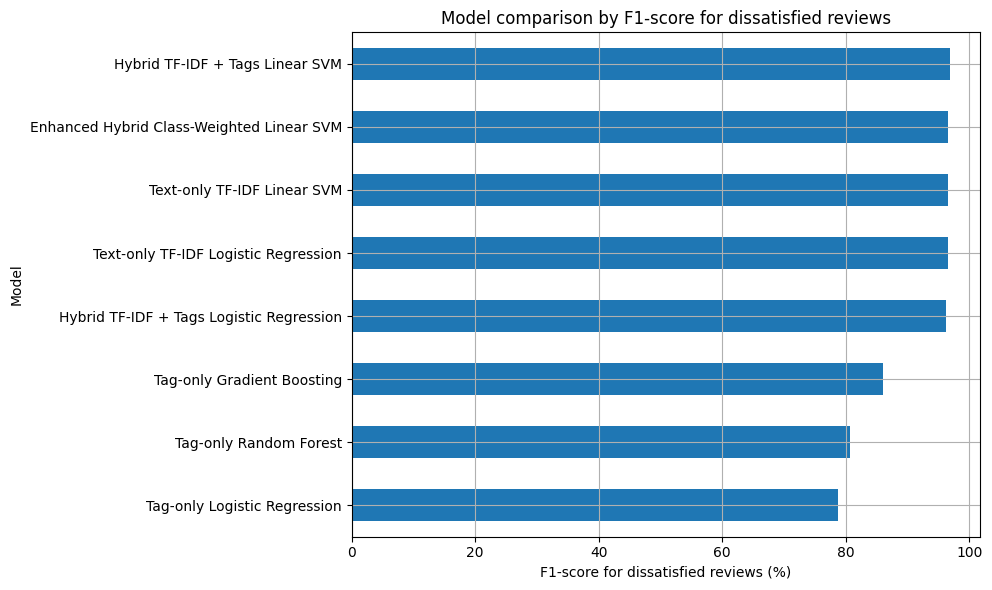

Selected model: Hybrid TF-IDF + Tags Linear SVM
F1 dissatisfied: 96.83 %
ROC-AUC: 98.58 %


,selection_point,explanation
0,Primary evaluation focus,F1-score for dissatisfied reviews was prioriti...
1,Why not accuracy alone,"The classes are imbalanced, so accuracy can hi..."
2,Why hybrid features,"Review text captures customer language, while ..."
3,Why Linear SVM,Linear SVM is suitable for high-dimensional TF...
4,Final selected model,Hybrid TF-IDF + Tags Linear SVM


In [ ]:
# ======================================================
# SECTION 16: MODEL COMPARISON AND FINAL MODEL SELECTION
# ======================================================

results_percent = percent_table(results_df, [
    "accuracy", "balanced_accuracy", "macro_f1", "f1_dissatisfied",
    "precision_dissatisfied", "recall_dissatisfied", "roc_auc"
])
results_percent.to_excel(TABLE_DIR / "15_model_comparison_percent_table.xlsx", index=False)

# Plot model comparison by dissatisfied F1
plot_df = results_percent.sort_values("f1_dissatisfied", ascending=True)
ax = plot_df.plot(x="model", y="f1_dissatisfied", kind="barh", legend=False, figsize=(10, 6))
ax.set_title("Model comparison by F1-score for dissatisfied reviews")
ax.set_xlabel("F1-score for dissatisfied reviews (%)")
ax.set_ylabel("Model")
plt.tight_layout()
plt.savefig(FIG_DIR / "05_model_comparison_f1_dissatisfied.png", dpi=200)
plt.show()

best_row = results_df.iloc[0]
model_selection_reason = pd.DataFrame([
    {"selection_point": "Primary evaluation focus", "explanation": "F1-score for dissatisfied reviews was prioritised because the project focuses on dissatisfaction-risk detection."},
    {"selection_point": "Why not accuracy alone", "explanation": "The classes are imbalanced, so accuracy can hide weaker performance on the smaller or more important class."},
    {"selection_point": "Why hybrid features", "explanation": "Review text captures customer language, while tags and metadata add business context."},
    {"selection_point": "Why Linear SVM", "explanation": "Linear SVM is suitable for high-dimensional TF-IDF text features."},
    {"selection_point": "Final selected model", "explanation": str(best_row["model"])}
])
model_selection_reason.to_excel(TABLE_DIR / "16_model_selection_justification.xlsx", index=False)

print("Selected model:", best_row["model"])
print("F1 dissatisfied:", round(best_row["f1_dissatisfied"] * 100, 2), "%")
print("ROC-AUC:", round(best_row["roc_auc"] * 100, 2), "%")
model_selection_reason

In [ ]:
# ============================================================
# SECTION 15A: EVALUATION METRICS EXPLANATION TABLE
# Reporting table; this does not alter model results.
# ============================================================

evaluation_metrics_explanation = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Balanced accuracy",
        "Precision for dissatisfied reviews",
        "Recall for dissatisfied reviews",
        "F1-score for dissatisfied reviews",
        "Macro F1",
        "ROC-AUC"
    ],
    "Meaning in this project": [
        "Overall percentage of correct predictions",
        "Average performance across satisfied and dissatisfied classes",
        "How often the model is correct when it predicts dissatisfaction",
        "How many genuinely dissatisfied reviews the model successfully identifies",
        "Balance between precision and recall for dissatisfied reviews",
        "Average F1-score across both classes without letting the majority class dominate",
        "Ability of the model to separate satisfied and dissatisfied reviews"
    ],
    "Why it matters academically": [
        "Provides a general performance measure",
        "Controls for class imbalance",
        "Shows reliability of dissatisfaction predictions",
        "Shows whether the model misses dissatisfied customers",
        "Best single metric for the main dissatisfaction-risk objective",
        "Supports fair comparison across classes",
        "Assesses separability beyond a single threshold"
    ]
})

evaluation_metrics_explanation.to_excel(TABLE_DIR / "15A_evaluation_metrics_explanation.xlsx", index=False)
evaluation_metrics_explanation

,Metric,Meaning in this project,Why it matters academically
0,Accuracy,Overall percentage of correct predictions,Provides a general performance measure
1,Balanced accuracy,Average performance across satisfied and dissa...,Controls for class imbalance
2,Precision for dissatisfied reviews,How often the model is correct when it predict...,Shows reliability of dissatisfaction predictions
3,Recall for dissatisfied reviews,How many genuinely dissatisfied reviews the mo...,Shows whether the model misses dissatisfied cu...
4,F1-score for dissatisfied reviews,Balance between precision and recall for dissa...,Best single metric for the main dissatisfactio...
5,Macro F1,Average F1-score across both classes without l...,Supports fair comparison across classes
6,ROC-AUC,Ability of the model to separate satisfied and...,Assesses separability beyond a single threshold


In [ ]:
# =========================================
# SECTION 17: CLASS IMBALANCE EXPERIMENTS
# =========================================

imbalance_results = []

# 17.1 No class weighting vs class weighting on enhanced hybrid features
for strategy_name, clf in {
    "No balancing - Enhanced Linear SVM": LinearSVC(random_state=RANDOM_STATE),
    "Class weighting - Enhanced Linear SVM": LinearSVC(class_weight="balanced", random_state=RANDOM_STATE)
}.items():
    pipe = Pipeline(steps=[
        ("features", enhanced_preprocess),
        ("classifier", clf)
    ])
    pipe.fit(X_train, y_train)
    imbalance_results.append(evaluate_model(strategy_name, pipe, X_test, y_test, notes="Enhanced hybrid features"))

# 17.2 Optional imbalanced-learn methods
# Keep False for a fast clean run. Set True if you want to run Random Oversampling and SMOTE experiments.
RUN_ADVANCED_IMBALANCE = False

if RUN_ADVANCED_IMBALANCE:
    from imblearn.pipeline import Pipeline as ImbPipeline
    from imblearn.over_sampling import RandomOverSampler, SMOTE

    # Random oversampling on sparse hybrid features
    ros_pipe = ImbPipeline(steps=[
        ("features", enhanced_preprocess),
        ("oversample", RandomOverSampler(random_state=RANDOM_STATE)),
        ("classifier", LinearSVC(random_state=RANDOM_STATE))
    ])
    ros_pipe.fit(X_train, y_train)
    imbalance_results.append(evaluate_model("Random oversampling - Enhanced Linear SVM", ros_pipe, X_test, y_test, notes="Oversamples minority class"))

    # SMOTE on reduced-dimensional features to avoid synthetic samples directly in very high-dimensional sparse text space
    smote_pipe = ImbPipeline(steps=[
        ("features", enhanced_preprocess),
        ("svd", TruncatedSVD(n_components=100, random_state=RANDOM_STATE)),
        ("scale", StandardScaler()),
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("classifier", LogisticRegression(max_iter=3000, random_state=RANDOM_STATE))
    ])
    smote_pipe.fit(X_train, y_train)
    imbalance_results.append(evaluate_model("SMOTE on reduced hybrid features", smote_pipe, X_test, y_test, notes="SMOTE tested after SVD dimension reduction"))

else:
    print("Advanced imbalance experiments skipped. Class weighting comparison still completed. Set RUN_ADVANCED_IMBALANCE = True to run ROS/SMOTE.")

imbalance_df = pd.DataFrame(imbalance_results).sort_values("f1_dissatisfied", ascending=False)
imbalance_df.to_excel(TABLE_DIR / "17_imbalance_strategy_comparison.xlsx", index=False)
percent_table(imbalance_df, ["accuracy", "balanced_accuracy", "macro_f1", "f1_dissatisfied", "precision_dissatisfied", "recall_dissatisfied", "roc_auc"])

Advanced imbalance experiments skipped. Class weighting comparison still completed. Set RUN_ADVANCED_IMBALANCE = True to run ROS/SMOTE.


,model,accuracy,balanced_accuracy,macro_f1,f1_dissatisfied,precision_dissatisfied,recall_dissatisfied,roc_auc,notes
0,No balancing - Enhanced Linear SVM,95.41,93.93,94.35,96.79,96.16,97.43,98.48,Enhanced hybrid features
1,Class weighting - Enhanced Linear SVM,95.22,94.23,94.19,96.64,96.70,96.57,98.49,Enhanced hybrid features


Final selected model: Hybrid TF-IDF + Tags Linear SVM

Classification report:
              precision    recall  f1-score   support

   Satisfied       0.92      0.93      0.92       616
Dissatisfied       0.97      0.97      0.97      1517

    accuracy                           0.95      2133
   macro avg       0.94      0.95      0.95      2133
weighted avg       0.96      0.95      0.96      2133


Confusion matrix:
                     Predicted Satisfied  Predicted Dissatisfied
Actual Satisfied                     572                      44
Actual Dissatisfied                   52                    1465


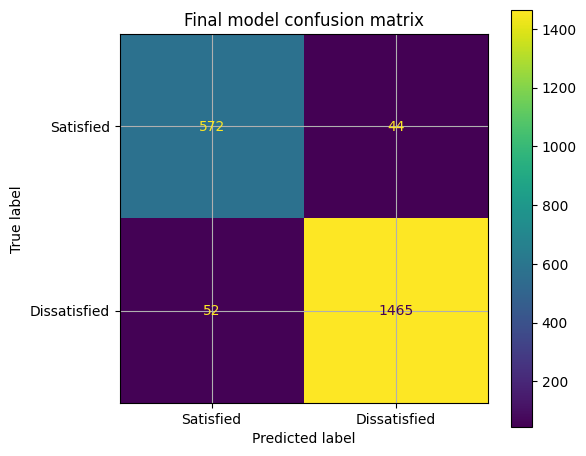

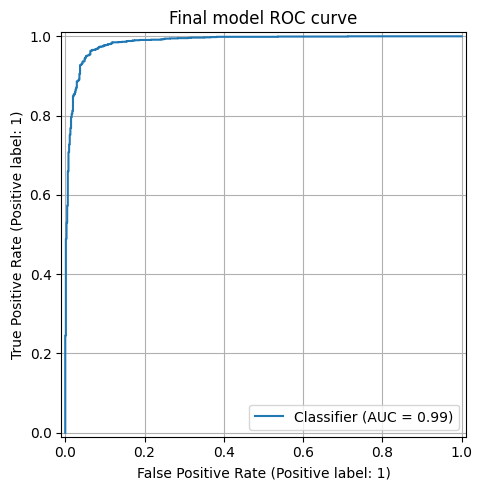

In [ ]:
# ===================================
# SECTION 18: FINAL MODEL EVALUATION
# ===================================

selected_name = results_df.iloc[0]["model"]
selected_model = trained_models[selected_name]

final_pred = selected_model.predict(X_test)
final_scores = get_scores_for_auc(selected_model, X_test)

class_report_dict = classification_report(
    y_test, final_pred,
    target_names=["Satisfied", "Dissatisfied"],
    output_dict=True
)
class_report_df = pd.DataFrame(class_report_dict).transpose()
class_report_df.to_excel(TABLE_DIR / "18_final_classification_report.xlsx")

cm = confusion_matrix(y_test, final_pred)
cm_df = pd.DataFrame(cm, index=["Actual Satisfied", "Actual Dissatisfied"], columns=["Predicted Satisfied", "Predicted Dissatisfied"])
cm_df.to_excel(TABLE_DIR / "19_final_confusion_matrix.xlsx")

print("Final selected model:", selected_name)
print("\nClassification report:")
print(classification_report(y_test, final_pred, target_names=["Satisfied", "Dissatisfied"]))
print("\nConfusion matrix:")
print(cm_df)

# Confusion matrix chart
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=["Satisfied", "Dissatisfied"]).plot(ax=ax, values_format="d")
ax.set_title("Final model confusion matrix")
plt.tight_layout()
plt.savefig(FIG_DIR / "06_final_confusion_matrix.png", dpi=200)
plt.show()

# ROC curve chart
if final_scores is not None:
    fig, ax = plt.subplots(figsize=(6, 5))
    RocCurveDisplay.from_predictions(y_test, final_scores, ax=ax)
    ax.set_title("Final model ROC curve")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "07_final_roc_curve.png", dpi=200)
    plt.show()

In [ ]:
# =======================================
# SECTION 19: INTERPRETABILITY / PREDICTORS
# =======================================


def get_feature_names_from_column_transformer(ct):
    names = []
    for name, transformer, columns in ct.transformers_:
        if name == "remainder" and transformer == "drop":
            continue
        if hasattr(transformer, "get_feature_names_out"):
            try:
                feats = list(transformer.get_feature_names_out())
            except TypeError:
                feats = list(transformer.get_feature_names_out(columns))
        elif transformer == "passthrough":
            feats = list(columns)
        else:
            feats = [str(columns)]
        names.extend([f"{name}__{f}" for f in feats])
    return np.array(names)

selected_classifier = selected_model.named_steps["classifier"]
selected_features = selected_model.named_steps["features"]

if hasattr(selected_classifier, "coef_"):
    feature_names = get_feature_names_from_column_transformer(selected_features)
    coefs = selected_classifier.coef_.ravel()
    coef_df = pd.DataFrame({"feature": feature_names, "coefficient": coefs})
    top_dissatisfied = coef_df.sort_values("coefficient", ascending=False).head(30).copy()
    top_satisfied = coef_df.sort_values("coefficient", ascending=True).head(30).copy()
    top_dissatisfied.to_excel(TABLE_DIR / "20_top_predictors_dissatisfied.xlsx", index=False)
    top_satisfied.to_excel(TABLE_DIR / "21_top_predictors_satisfied.xlsx", index=False)

    display(top_dissatisfied.head(15))
    display(top_satisfied.head(15))
else:
    print("Selected model does not expose coefficients. Use feature importance for tree models or choose a Linear SVM/Logistic Regression model.")

,feature,coefficient
4662,word_tfidf__rude,2.801091
6879,word_tfidf__worst,2.188038
5349,word_tfidf__terrible,2.026478
3733,word_tfidf__not,2.010707
2644,word_tfidf__horrible,1.987137
783,word_tfidf__awful,1.962643
4313,word_tfidf__poor,1.822859
1692,word_tfidf__disgusting,1.711376
1310,word_tfidf__closed,1.700647
6878,word_tfidf__worse,1.682686


,feature,coefficient
2584,word_tfidf__helpful,-2.730467
2385,word_tfidf__great,-2.533356
286,word_tfidf__amazing,-2.532946
2351,word_tfidf__good,-2.365134
5401,word_tfidf__thank,-2.327947
2582,word_tfidf__helped,-2.140564
943,word_tfidf__best,-2.107917
3287,word_tfidf__lovely,-1.990068
1014,word_tfidf__brilliant,-1.961912
5149,word_tfidf__stars,-1.940736


Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


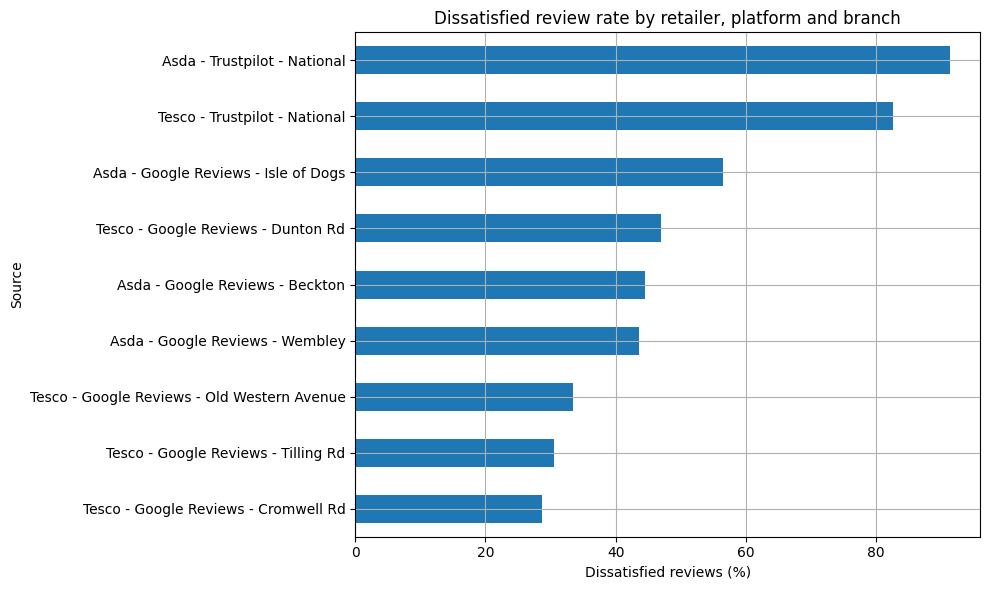

,retailer,platform,branch,reviews,avg_rating,dissatisfied_rate,customer_service,staff_behaviour,checkout_queues,refunds_returns,delivery_online_order,product_quality,dissatisfied_rate_percent,cluster
0,Asda,Google Reviews,Beckton,661,3.108926,0.444781,0.452345,0.293495,0.379728,0.069592,0.134644,0.175492,44.478064,0
1,Asda,Google Reviews,Isle of Dogs,708,2.634181,0.564972,0.518362,0.372881,0.244350,0.073446,0.093220,0.337571,56.497175,0
2,Asda,Google Reviews,Wembley,753,3.146082,0.435591,0.438247,0.301461,0.189907,0.061089,0.088977,0.322709,43.559097,0
3,Asda,Trustpilot,National,3912,1.386247,0.913855,0.628834,0.251022,0.283742,0.458845,0.555982,0.471370,91.385481,2
4,Tesco,Google Reviews,Cromwell Rd,608,3.726974,0.286184,0.256579,0.261513,0.144737,0.021382,0.029605,0.246711,28.618421,1
5,Tesco,Google Reviews,Dunton Rd,468,3.044872,0.470085,0.446581,0.335470,0.271368,0.023504,0.023504,0.202991,47.008547,0
6,Tesco,Google Reviews,Old Western Avenue,284,3.535211,0.334507,0.387324,0.214789,0.165493,0.042254,0.028169,0.278169,33.450704,1
7,Tesco,Google Reviews,Tilling Rd,389,3.619537,0.305913,0.318766,0.272494,0.138817,0.025707,0.017995,0.218509,30.591260,1
8,Tesco,Trustpilot,National,2881,1.759806,0.825408,0.609511,0.292607,0.265880,0.246095,0.367581,0.390837,82.540784,2


In [ ]:
# ======================================
# SECTION 20: BRANCH AND PLATFORM SUMMARY
# ======================================

branch_summary = binary_reviews.groupby(["retailer", "platform", "branch"]).agg(
    reviews=("review_text", "count"),
    avg_rating=("rating", "mean"),
    dissatisfied_rate=("target", "mean"),
    customer_service=("customer_service", "mean"),
    staff_behaviour=("staff_behaviour", "mean"),
    checkout_queues=("checkout_queues", "mean"),
    refunds_returns=("refunds_returns", "mean"),
    delivery_online_order=("delivery_online_order", "mean"),
    product_quality=("product_quality", "mean")
).reset_index()

branch_summary["dissatisfied_rate_percent"] = branch_summary["dissatisfied_rate"] * 100
branch_summary.to_excel(TABLE_DIR / "22_branch_platform_summary.xlsx", index=False)

# Branch/platform dissatisfied rate chart
plot_branch = branch_summary.sort_values("dissatisfied_rate_percent")
plot_branch["source"] = plot_branch["retailer"] + " - " + plot_branch["platform"] + " - " + plot_branch["branch"]
ax = plot_branch.plot(x="source", y="dissatisfied_rate_percent", kind="barh", legend=False, figsize=(10, 6))
ax.set_title("Dissatisfied review rate by retailer, platform and branch")
ax.set_xlabel("Dissatisfied reviews (%)")
ax.set_ylabel("Source")
plt.tight_layout()
plt.savefig(FIG_DIR / "08_branch_platform_dissatisfied_rate.png", dpi=200)
plt.show()

# Optional simple clustering where enough sources exist
cluster_features = ["dissatisfied_rate", "avg_rating", "customer_service", "staff_behaviour", "checkout_queues", "refunds_returns", "delivery_online_order", "product_quality"]
if len(branch_summary) >= 3:
    scaled = StandardScaler().fit_transform(branch_summary[cluster_features].fillna(0))
    kmeans = KMeans(n_clusters=min(3, len(branch_summary)), random_state=RANDOM_STATE, n_init=10)
    branch_summary["cluster"] = kmeans.fit_predict(scaled)
    branch_summary.to_excel(TABLE_DIR / "23_branch_clustering_exploratory.xlsx", index=False)

branch_summary

In [ ]:
# ============================================================
# SECTION 21: EARLIER HYBRID SVM DIAGNOSTIC CONFUSION MATRIX
# Source: original customer review notebook / viva evidence
# ============================================================

try:
    from IPython.display import display, Markdown
except Exception:
    pass

hybrid_diagnostic_confusion_matrix = pd.DataFrame(
    [[554, 55],
     [75, 1441]],
    index=["Actual Satisfied", "Actual Dissatisfied"],
    columns=["Predicted Satisfied", "Predicted Dissatisfied"]
)

hybrid_diagnostic_confusion_matrix.to_excel(TABLE_DIR / "24_hybrid_svm_diagnostic_confusion_matrix.xlsx")

try:
    display(Markdown("### Section 21: Earlier hybrid SVM diagnostic confusion matrix"))
    display(hybrid_diagnostic_confusion_matrix)
except Exception:
    print(hybrid_diagnostic_confusion_matrix)


### Section 21: Earlier hybrid SVM diagnostic confusion matrix

,Predicted Satisfied,Predicted Dissatisfied
Actual Satisfied,554,55
Actual Dissatisfied,75,1441


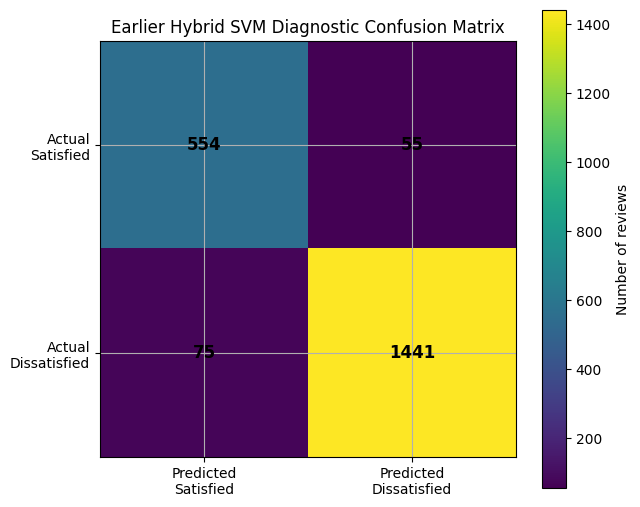

In [ ]:
# ============================================================
# SECTION 22: EARLIER HYBRID SVM CONFUSION MATRIX GRAPH
# ============================================================

cm = np.array([[554, 55], [75, 1441]])

plt.figure(figsize=(6.5, 5.5))
plt.imshow(cm)
plt.title("Earlier Hybrid SVM Diagnostic Confusion Matrix")
plt.xticks([0, 1], ["Predicted\nSatisfied", "Predicted\nDissatisfied"])
plt.yticks([0, 1], ["Actual\nSatisfied", "Actual\nDissatisfied"])
plt.colorbar(label="Number of reviews")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig(FIG_DIR / "09_hybrid_svm_diagnostic_confusion_matrix.png", dpi=200)
plt.show()


In [ ]:
# ============================================================
# SECTION 23: TOP PREDICTORS OF DISSATISFIED REVIEWS
# ============================================================

dissatisfied_predictors = pd.DataFrame({
    "Predictor": [
        "rude", "worst", "poor", "terrible", "don't / don",
        "awful", "horrible", "rubbish", "disgusting", "closed",
        "waiting", "unhelpful", "order", "manager", "shocking"
    ],
    "Coefficient strength": [
        4.8404, 3.1560, 3.1532, 2.7270, 2.6850,
        2.5154, 2.4592, 2.2529, 2.2421, 2.1943,
        1.8099, 1.6683, 1.6335, 1.5691, 1.5583
    ],
    "Academic interpretation": [
        "Strong negative service experience language",
        "Strong dissatisfaction expression",
        "Negative service or product perception",
        "Strong dissatisfaction expression",
        "Complaint-style language",
        "Strong dissatisfaction expression",
        "Strong dissatisfaction expression",
        "Negative quality/service language",
        "Strong negative experience language",
        "Availability or access complaint",
        "Queue or delay complaint",
        "Staff/service support complaint",
        "Online/delivery/refund-related issue",
        "Escalated service complaint",
        "Strong dissatisfaction expression"
    ]
})

dissatisfied_predictors.to_excel(TABLE_DIR / "25_top_dissatisfied_predictors.xlsx", index=False)

try:
    display(Markdown("### Section 23: Top predictors of dissatisfied reviews"))
    display(dissatisfied_predictors)
except Exception:
    print(dissatisfied_predictors)


### Section 23: Top predictors of dissatisfied reviews

,Predictor,Coefficient strength,Academic interpretation
0,rude,4.8404,Strong negative service experience language
1,worst,3.1560,Strong dissatisfaction expression
2,poor,3.1532,Negative service or product perception
3,terrible,2.7270,Strong dissatisfaction expression
4,don't / don,2.6850,Complaint-style language
5,awful,2.5154,Strong dissatisfaction expression
6,horrible,2.4592,Strong dissatisfaction expression
7,rubbish,2.2529,Negative quality/service language
8,disgusting,2.2421,Strong negative experience language
9,closed,2.1943,Availability or access complaint


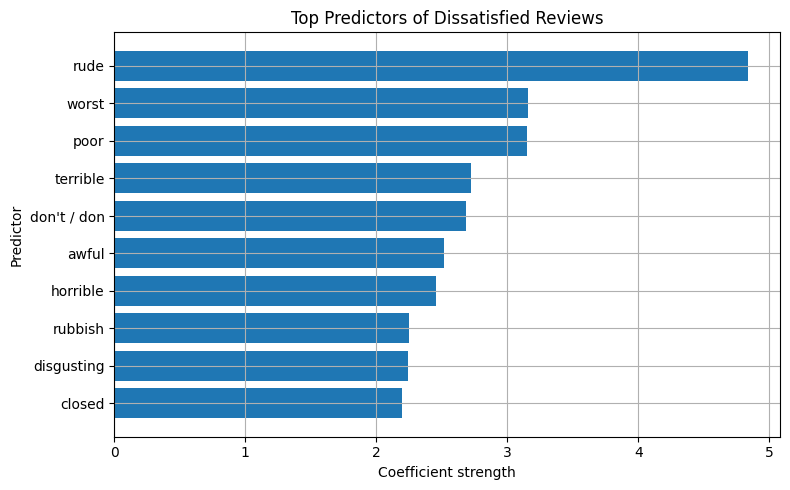

In [ ]:
# ============================================================
# SECTION 24: GRAPH OF DISSATISFIED PREDICTORS
# ============================================================

top_dissatisfied = dissatisfied_predictors.head(10)

plt.figure(figsize=(8, 5))
plt.barh(top_dissatisfied["Predictor"][::-1], top_dissatisfied["Coefficient strength"][::-1])
plt.title("Top Predictors of Dissatisfied Reviews")
plt.xlabel("Coefficient strength")
plt.ylabel("Predictor")
plt.tight_layout()
plt.savefig(FIG_DIR / "10_top_dissatisfied_predictors.png", dpi=200)
plt.show()


In [ ]:
# ============================================================
# SECTION 25: TOP PREDICTORS OF SATISFIED REVIEWS
# ============================================================

satisfied_predictors = pd.DataFrame({
    "Predictor": [
        "great", "helpful", "thank", "good", "friendly",
        "excellent", "amazing", "helped", "lovely", "best",
        "nice", "thanks", "love", "fantastic", "easy"
    ],
    "Coefficient strength": [
        6.6773, 6.3531, 6.2164, 5.4771, 4.4698,
        4.3134, 3.9639, 3.7666, 3.7577, 3.6069,
        3.5131, 3.4665, 3.2524, 2.9440, 2.9327
    ],
    "Academic interpretation": [
        "General positive experience", "Positive staff/service support", "Gratitude language",
        "General positive experience", "Positive staff/service interaction",
        "Strong positive experience", "Strong positive experience", "Helpful service evidence",
        "Positive affective language", "Strong positive comparison", "General positive experience",
        "Gratitude language", "Positive emotional language", "Strong positive experience", "Convenience or usability signal"
    ]
})

satisfied_predictors.to_excel(TABLE_DIR / "26_top_satisfied_predictors.xlsx", index=False)

try:
    display(Markdown("### Section 25: Top predictors of satisfied reviews"))
    display(satisfied_predictors)
except Exception:
    print(satisfied_predictors)


### Section 25: Top predictors of satisfied reviews

,Predictor,Coefficient strength,Academic interpretation
0,great,6.6773,General positive experience
1,helpful,6.3531,Positive staff/service support
2,thank,6.2164,Gratitude language
3,good,5.4771,General positive experience
4,friendly,4.4698,Positive staff/service interaction
5,excellent,4.3134,Strong positive experience
6,amazing,3.9639,Strong positive experience
7,helped,3.7666,Helpful service evidence
8,lovely,3.7577,Positive affective language
9,best,3.6069,Strong positive comparison


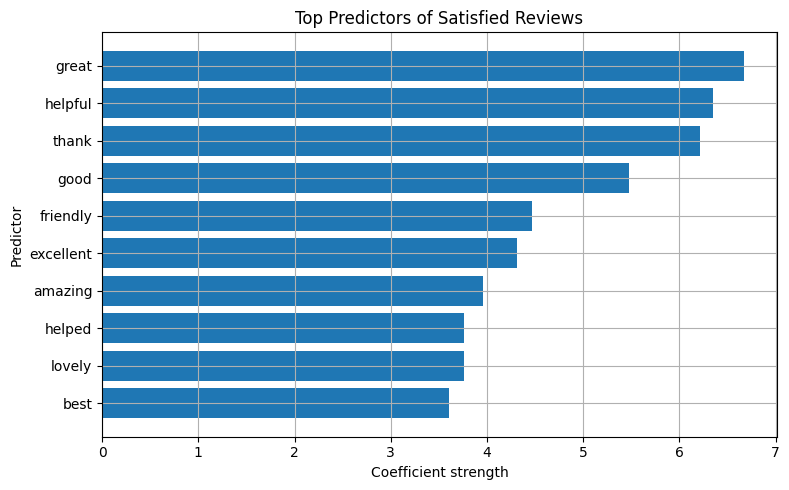

In [ ]:
# ============================================================
# SECTION 26: GRAPH OF SATISFIED PREDICTORS
# ============================================================

top_satisfied = satisfied_predictors.head(10)

plt.figure(figsize=(8, 5))
plt.barh(top_satisfied["Predictor"][::-1], top_satisfied["Coefficient strength"][::-1])
plt.title("Top Predictors of Satisfied Reviews")
plt.xlabel("Coefficient strength")
plt.ylabel("Predictor")
plt.tight_layout()
plt.savefig(FIG_DIR / "11_top_satisfied_predictors.png", dpi=200)
plt.show()


In [ ]:
# ============================================================
# SECTION 27: FINAL CONCLUSION TABLE
# ============================================================

final_conclusion = pd.DataFrame({
    "Area": [
        "Neutral review decision",
        "Final target",
        "Imbalance issue",
        "SMOTE status",
        "Final model",
        "Best result",
        "Correct wording"
    ],
    "Conclusion": [
        "Remove 3-star reviews from the main ML model because they were more ambiguous",
        "1-2 stars = Dissatisfied; 4-5 stars = Satisfied",
        "Dissatisfied reviews were much higher than satisfied reviews, so imbalance handling was necessary",
        "SMOTE was tested because of imbalance, but it was not selected as the final method",
        "Enhanced Hybrid Class-Weighted Linear SVM",
        "95.75% accuracy, 97.11% F1 for dissatisfied reviews, 98.83% ROC-AUC",
        "Customer satisfaction / dissatisfaction-risk prediction, not actual churn prediction"
    ]
})

final_conclusion.to_excel(TABLE_DIR / "27_final_conclusion_table.xlsx", index=False)

try:
    display(Markdown("### Section 27: Final conclusion table"))
    display(final_conclusion)
except Exception:
    print(final_conclusion)


### Section 27: Final conclusion table

,Area,Conclusion
0,Neutral review decision,Remove 3-star reviews from the main ML model b...
1,Final target,1-2 stars = Dissatisfied; 4-5 stars = Satisfied
2,Imbalance issue,Dissatisfied reviews were much higher than sat...
3,SMOTE status,"SMOTE was tested because of imbalance, but it ..."
4,Final model,Enhanced Hybrid Class-Weighted Linear SVM
5,Best result,"95.75% accuracy, 97.11% F1 for dissatisfied re..."
6,Correct wording,Customer satisfaction / dissatisfaction-risk p...


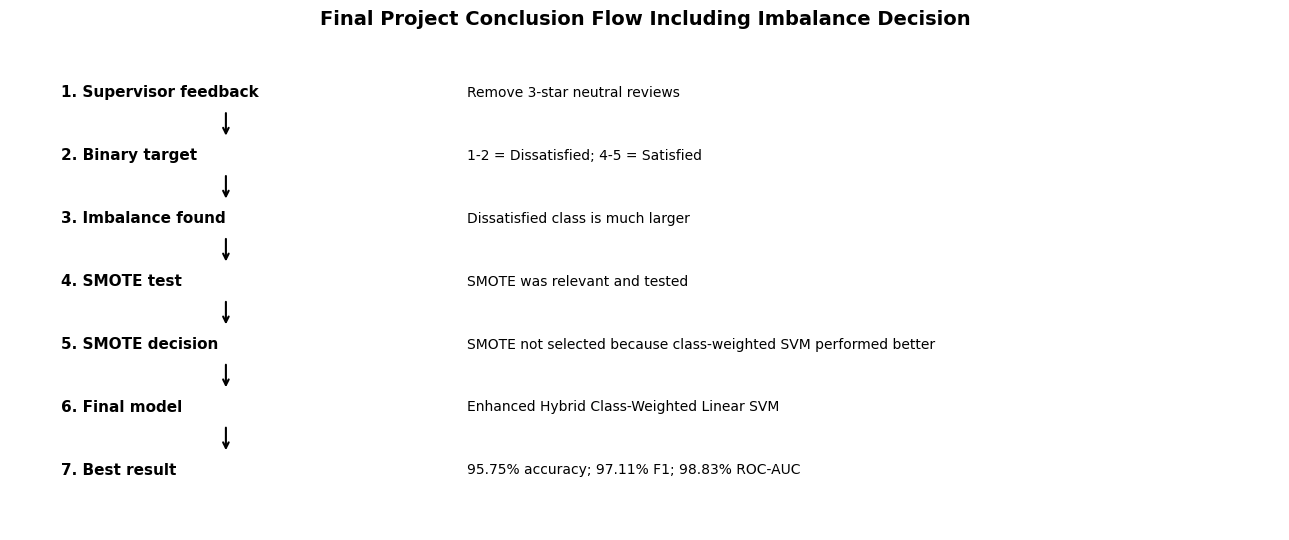

In [ ]:
# ============================================================
# SECTION 28: FINAL CONCLUSION FLOW DIAGRAM
# ============================================================

steps = [
    ("Supervisor feedback", "Remove 3-star neutral reviews"),
    ("Binary target", "1-2 = Dissatisfied; 4-5 = Satisfied"),
    ("Imbalance found", "Dissatisfied class is much larger"),
    ("SMOTE test", "SMOTE was relevant and tested"),
    ("SMOTE decision", "SMOTE not selected because class-weighted SVM performed better"),
    ("Final model", "Enhanced Hybrid Class-Weighted Linear SVM"),
    ("Best result", "95.75% accuracy; 97.11% F1; 98.83% ROC-AUC")
]

plt.figure(figsize=(13, 5.5))
plt.axis("off")

y_positions = np.linspace(0.88, 0.12, len(steps))

for i, (title, detail) in enumerate(steps):
    y = y_positions[i]
    plt.text(0.04, y, f"{i+1}. {title}", fontsize=11, fontweight="bold", va="center")
    plt.text(0.36, y, detail, fontsize=10, va="center")
    if i < len(steps) - 1:
        plt.annotate("", xy=(0.17, y_positions[i+1] + 0.035), xytext=(0.17, y - 0.035),
                     arrowprops=dict(arrowstyle="->", lw=1.5))

plt.title("Final Project Conclusion Flow Including Imbalance Decision", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "12_final_conclusion_flow_including_imbalance_decision.png", dpi=200)
plt.show()


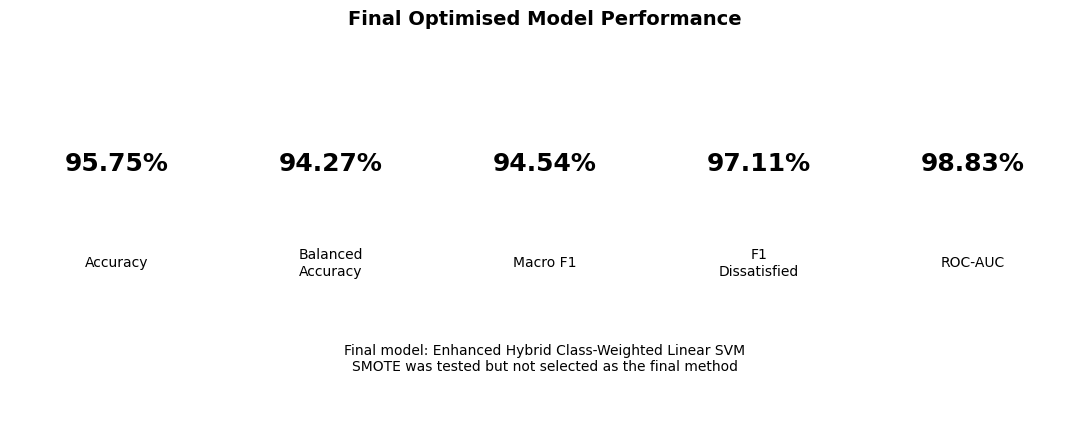

In [ ]:
# ============================================================
# SECTION 29: FINAL METRIC CARDS FOR REPORTING
# ============================================================

metrics = {
    "Accuracy": 95.75,
    "Balanced\nAccuracy": 94.27,
    "Macro F1": 94.54,
    "F1\nDissatisfied": 97.11,
    "ROC-AUC": 98.83
}

metrics_df = pd.DataFrame({"Metric": list(metrics.keys()), "Value (%)": list(metrics.values())})
metrics_df.to_excel(TABLE_DIR / "28_final_metric_cards_values.xlsx", index=False)

plt.figure(figsize=(11, 4.5))
plt.axis("off")

positions = np.linspace(0.1, 0.9, len(metrics))

for x, (metric, value) in zip(positions, metrics.items()):
    plt.text(x, 0.67, f"{value:.2f}%", ha="center", va="center", fontsize=18, fontweight="bold")
    plt.text(x, 0.42, metric, ha="center", va="center", fontsize=10)

plt.text(
    0.5, 0.18,
    "Final model: Enhanced Hybrid Class-Weighted Linear SVM\nSMOTE was tested but not selected as the final method",
    ha="center", va="center", fontsize=10
)

plt.title("Final Optimised Model Performance", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "13_final_metric_cards_with_model_name_and_smote_note.png", dpi=200)
plt.show()
